In [1]:
# create a script to check if the image is all black and delete it.
import os
import sys
import matplotlib.image as mpimg
import numpy as np


In [2]:
image_dir = "New_galaxies"

In [3]:
for filename in os.listdir(image_dir):
    img = mpimg.imread(image_dir+"/"+filename)
    if np.allclose(img, 0, atol=1e-3):
        print(f"Deleting {filename} because it is all black")
        os.remove(image_dir+"/"+filename)
    else:
        print(f"{filename} is not all black")
        # Uncomment the next line to keep the image
        # os.rename(filename, os.path.join(image_dir, filename))


NGVS_RGB_cutout_Galaxy484.jpeg is not all black
NGVS_RGB_cutout_Galaxy16.jpeg is not all black
NGVS_RGB_cutout_Galaxy191.jpeg is not all black
NGVS_RGB_cutout_Galaxy312.jpeg is not all black
NGVS_RGB_cutout_Galaxy257.jpeg is not all black
NGVS_RGB_cutout_Galaxy129.jpeg is not all black
NGVS_RGB_cutout_Galaxy41.jpeg is not all black
NGVS_RGB_cutout_Galaxy2.jpeg is not all black
NGVS_RGB_cutout_Galaxy345.jpeg is not all black
NGVS_RGB_cutout_Galaxy200.jpeg is not all black
NGVS_RGB_cutout_Galaxy57.jpeg is not all black
NGVS_RGB_cutout_Galaxy353.jpeg is not all black
NGVS_RGB_cutout_Galaxy216.jpeg is not all black
NGVS_RGB_cutout_Galaxy168.jpeg is not all black
NGVS_RGB_cutout_Galaxy492.jpeg is not all black
NGVS_RGB_cutout_Galaxy187.jpeg is not all black
NGVS_RGB_cutout_Galaxy304.jpeg is not all black
NGVS_RGB_cutout_Galaxy241.jpeg is not all black
NGVS_RGB_cutout_Galaxy94.jpeg is not all black
NGVS_RGB_cutout_Galaxy406.jpeg is not all black
NGVS_RGB_cutout_Galaxy113.jpeg is not all blac

In [15]:
import matplotlib.colors
import matplotlib.pyplot as plt

# check if majority of the image is too white or yellow
def is_white_or_yellow(image, threshold=0.9):
    # Convert the image to HSV color space
    # Normalize image data to 0-1 range for rgb_to_hsv if it's uint8
    if image.dtype == np.uint8:
        image = image / 255.0
    hsv_image = matplotlib.colors.rgb_to_hsv(image)

    # Check if the majority of pixels are white or yellow
    white_pixels = np.sum(hsv_image[:, :, 2] > threshold)
    yellow_pixels = np.sum((hsv_image[:, :, 0] > 0.1) & (hsv_image[:, :, 0] < 0.2) & (hsv_image[:, :, 1] > threshold))
    
    total_pixels = image.shape[0] * image.shape[1]
    
    return (white_pixels + yellow_pixels) / total_pixels > 0.5
# Check if the image is too white or yellow
count = 0
for filename in os.listdir(image_dir):
    img = mpimg.imread(image_dir+"/"+filename)
    if is_white_or_yellow(img):
        print(f"Deleting {filename} because it is too white or yellow")
        plt.imshow(img)
        plt.show()
        count += 1
        #os.remove(image_dir+"/"+filename)
    else:
        continue
        #print(f"{filename} is not too white or yellow")
        # Uncomment the next line to keep the image
        # os.rename(filename, os.path.join(image_dir, filename))

In [12]:
len(os.listdir("New_galaxies"))

438

In [22]:
import matplotlib.colors
import matplotlib.pyplot as plt
import os
import numpy as np
import matplotlib.image as mpimg

# Check if the majority of the image is too white or yellow
def proportion_white_or_yellow(image, threshold=0.9):
    # Convert the image to HSV color space
    # Normalize image data to 0-1 range for rgb_to_hsv if it's uint8
    if image.dtype == np.uint8:
        image = image / 255.0
    hsv_image = matplotlib.colors.rgb_to_hsv(image)

    # Calculate the proportion of white and yellow pixels
    white_pixels = np.sum(hsv_image[:, :, 2] > threshold)
    yellow_pixels = np.sum((hsv_image[:, :, 0] > 0.1) & (hsv_image[:, :, 0] < 0.2) & (hsv_image[:, :, 1] > threshold))
    
    total_pixels = image.shape[0] * image.shape[1]
    return (white_pixels + yellow_pixels) / total_pixels

# Directory containing the images
image_dir = "galaxy_train"

# Store the proportion of white/yellow pixels for each image
image_proportions = []

for filename in os.listdir(image_dir):
    img = mpimg.imread(os.path.join(image_dir, filename))
    proportion = proportion_white_or_yellow(img)
    image_proportions.append((filename, proportion))


In [23]:

# Sort images by the proportion of white/yellow pixels in ascending order
image_proportions.sort(key=lambda x: x[1])


NGVS_RGB_cutout_Galaxy97_aug_0.jpeg has 0.67% white or yellow pixels


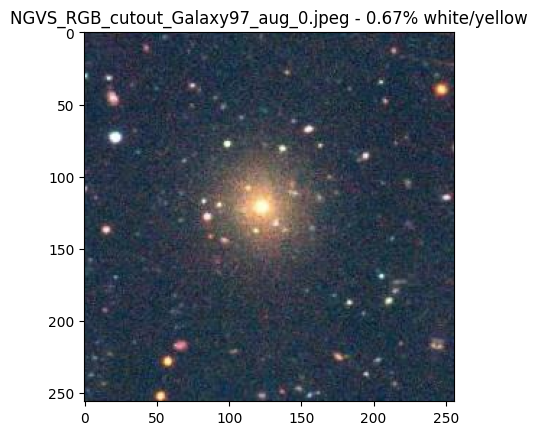

NGVS_RGB_cutout_Galaxy97_aug_1.jpeg has 0.96% white or yellow pixels


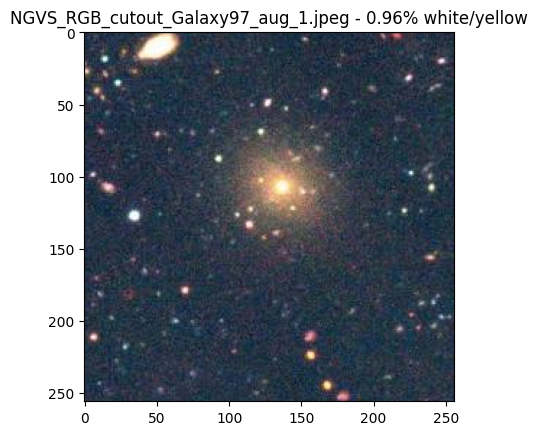

NGVS_RGB_cutout_Galaxy483_aug_1.jpeg has 1.16% white or yellow pixels


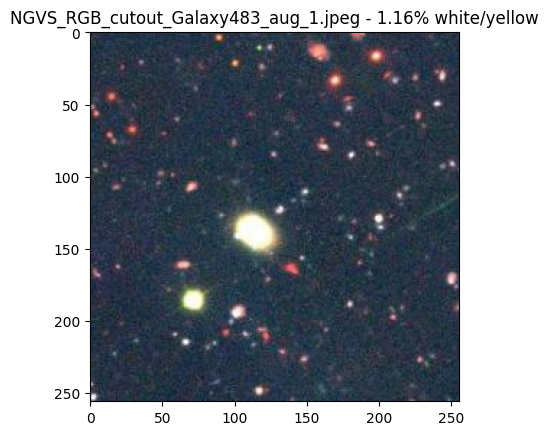

NGVS_RGB_cutout_Galaxy368_aug_1.jpeg has 1.24% white or yellow pixels


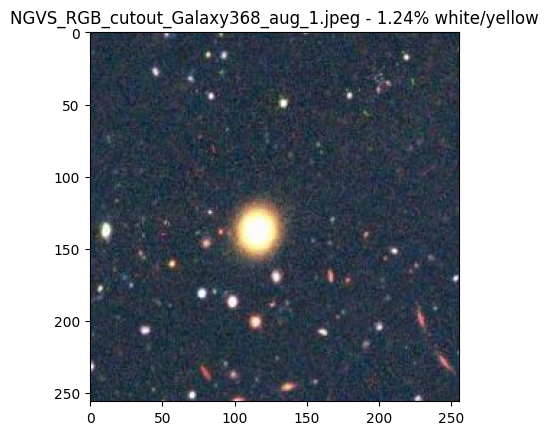

NGVS_RGB_cutout_Galaxy368_aug_0.jpeg has 1.27% white or yellow pixels


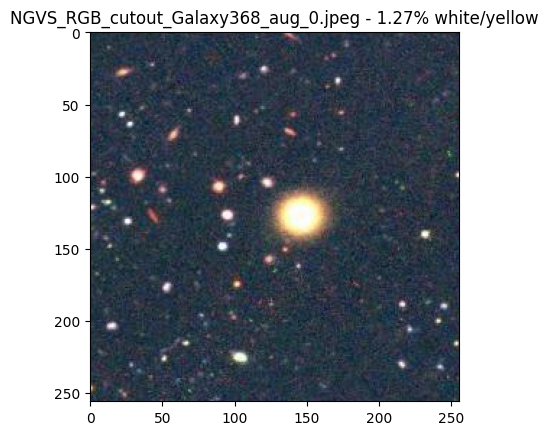

NGVS_RGB_cutout_Galaxy483_aug_0.jpeg has 1.36% white or yellow pixels


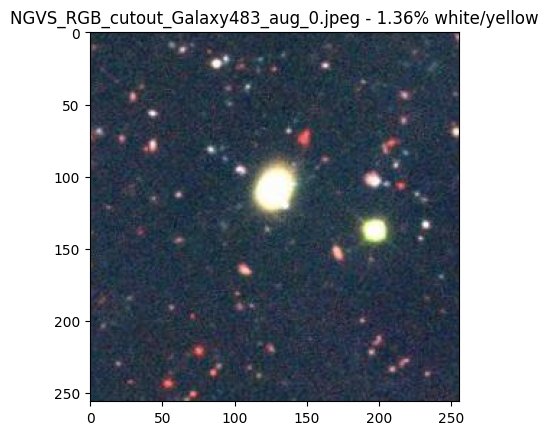

NGVS_RGB_cutout_Galaxy345_aug_0.jpeg has 1.37% white or yellow pixels


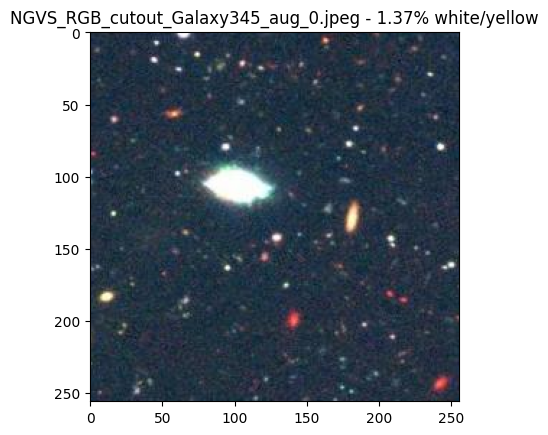

NGVS_RGB_cutout_Galaxy345_aug_1.jpeg has 1.39% white or yellow pixels


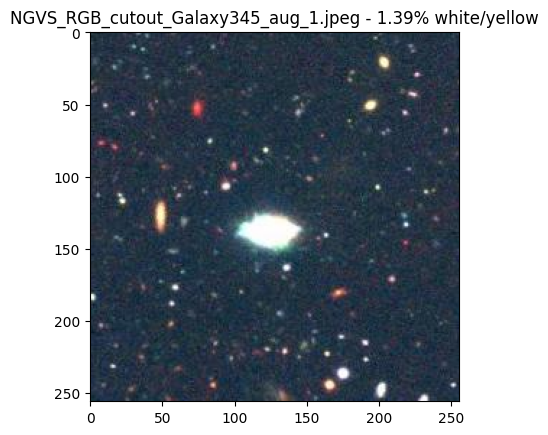

NGVS_RGB_cutout_Galaxy5_aug_1.jpeg has 1.45% white or yellow pixels


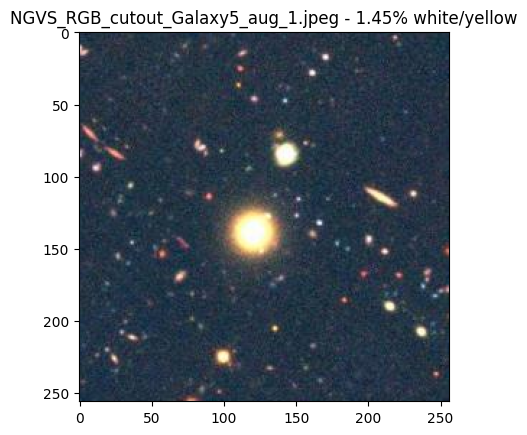

NGVS_RGB_cutout_Galaxy36_aug_1.jpeg has 1.61% white or yellow pixels


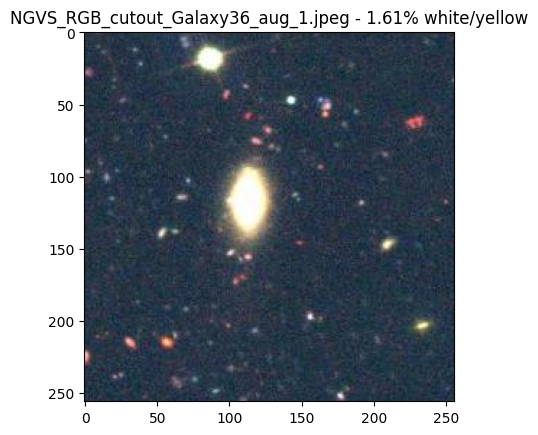

NGVS_RGB_cutout_Galaxy353_aug_0.jpeg has 1.63% white or yellow pixels


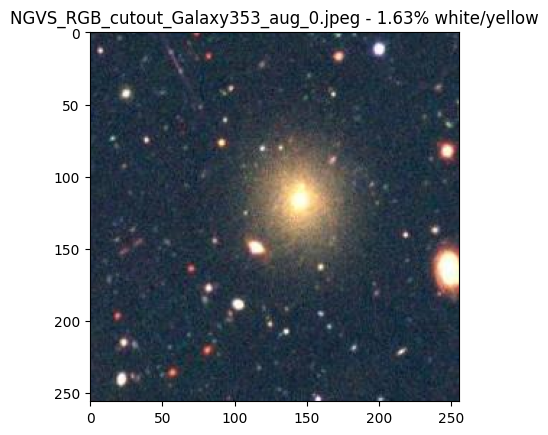

NGVS_RGB_cutout_Galaxy360_aug_0.jpeg has 1.64% white or yellow pixels


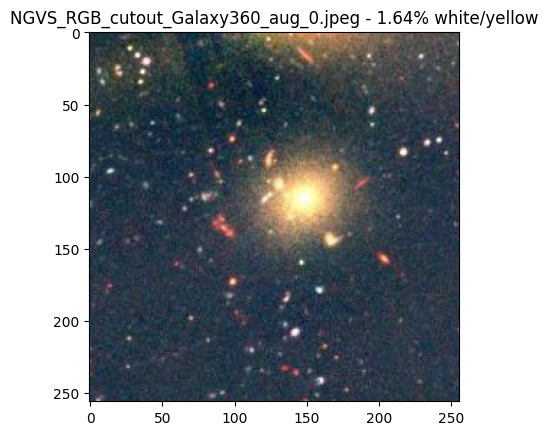

NGVS_RGB_cutout_Galaxy360_aug_1.jpeg has 1.66% white or yellow pixels


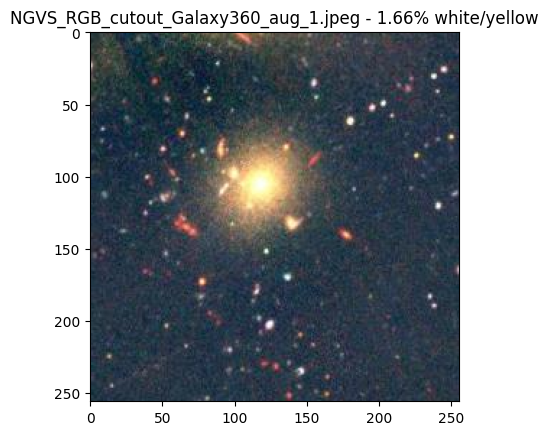

NGVS_RGB_cutout_Galaxy58_aug_0.jpeg has 1.67% white or yellow pixels


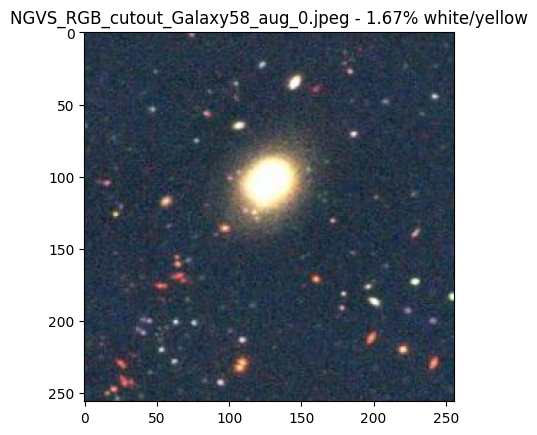

NGVS_RGB_cutout_Galaxy285_aug_0.jpeg has 1.75% white or yellow pixels


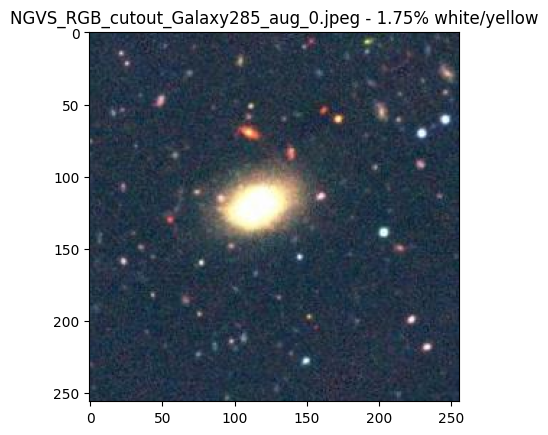

NGVS_RGB_cutout_Galaxy211_aug_1.jpeg has 1.75% white or yellow pixels


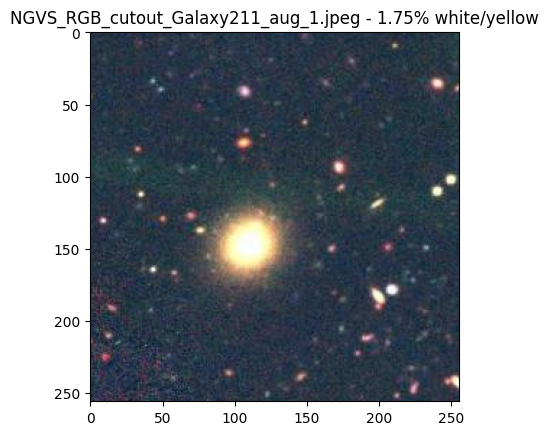

NGVS_RGB_cutout_Galaxy211_aug_0.jpeg has 1.75% white or yellow pixels


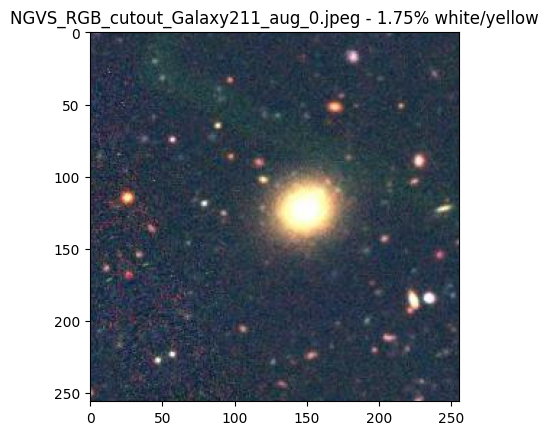

NGVS_RGB_cutout_Galaxy58_aug_1.jpeg has 1.77% white or yellow pixels


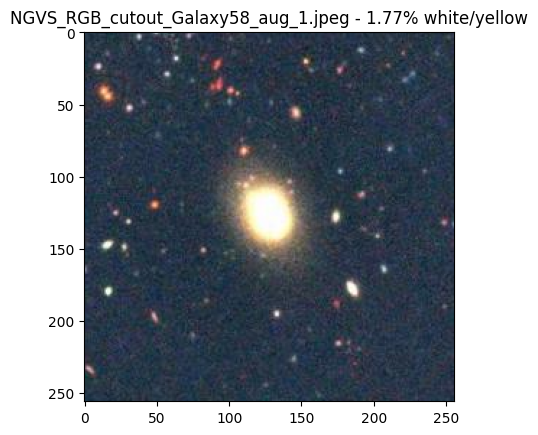

NGVS_RGB_cutout_Galaxy61_aug_1.jpeg has 1.78% white or yellow pixels


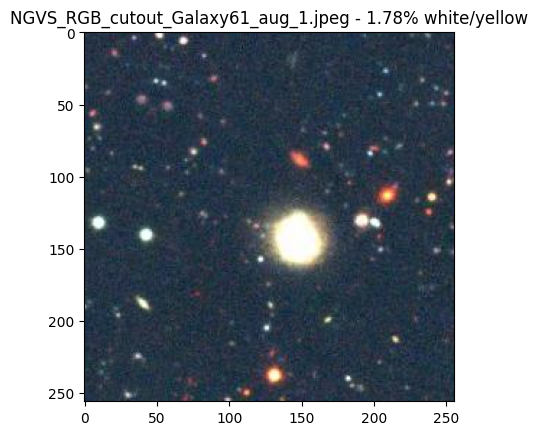

NGVS_RGB_cutout_Galaxy36_aug_0.jpeg has 1.82% white or yellow pixels


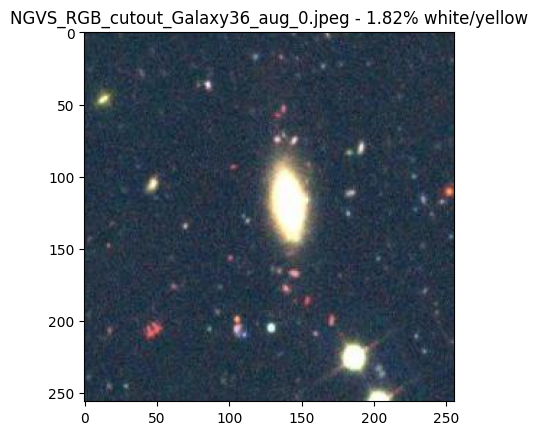

In [24]:

# Display the images with the least amount of yellow or white
for filename, proportion in image_proportions[:20]:  # Adjust the number of images to display
    print(f"{filename} has {proportion:.2%} white or yellow pixels")
    img = mpimg.imread(os.path.join(image_dir, filename))
    plt.imshow(img)
    plt.title(f"{filename} - {proportion:.2%} white/yellow")
    plt.show()